# 10-2 트랜스포머의 변형 - 인코더만 사용하는 트랜스포머

본 노트북은 10-2절 본문 예제 [코드 10-7], [코드 10-8]을 모아 위에서 아래로
실행해 본다. `nn.TransformerEncoder`와 `nn.TransformerEncoderLayer`로
인코더만 사용하는 트랜스포머를 만들어, 입력 날짜 문자열이 정상 형식인지
검증하는 `DateValidator` 모델(모델 13)을 학습한다.

다루는 내용
- 인코더만 사용하는 트랜스포머 `DateValidator` 클래스 ([코드 10-7])
- 분류 결과의 신뢰도를 함께 출력하는 예측 함수 ([코드 10-8])
- 입력 유형별 분류 정확도와 평균 신뢰도 측정 ([표 10-7])

데이터 생성, 어휘 사전, `[CLS]` 토큰을 추가하는 데이터셋, 학습 함수는
노트북에서 직접 정의한다. 위치 인코딩 `PositionalEncoding`은 10-1절
[코드 10-1]과 동일하다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 10장 예제는 PyTorch 기본 패키지만으로 동작한다.
# !pip install -q matplotlib numpy torch

In [2]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [ ]:
# 참고 - 시드 고정과 학습 장치 객체 생성
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## 정상/비정상 날짜 문자열 데이터 생성

정상 날짜 문자열은 `datetime`으로 무작위 날짜를 골라 8가지 형식 중 하나로
만든다. 비정상 날짜 문자열은 형식은 비슷하지만 구분자/순서/존재하지 않는
날짜 등으로 어긋난 패턴([표 10-6])을 만든다. 정상(1)/비정상(0) 레이블과
함께 5,000개를 생성해 훈련 4,000 + 검증 1,000으로 나눈다.

In [ ]:
# 참고 - 정상 / 비정상 날짜 문자열 데이터 생성
from datetime import datetime, timedelta
import random
import calendar
# 본문 [표 10-6] 의 정상 형식 8 가지 (10-1 절과 동일)
# src_formats = [
#     '%d %B %Y', '%d %b %Y',
#     '%B %d, %Y', '%b %d, %Y',
#     '%m/%d/%Y', '%Y/%m/%d',
#     '%d-%m-%Y', '%Y-%m-%d',
# ]

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# 무작위 형식으로 정상 날짜 문자열을 생성하는 함수
def make_valid_date_str(date):
    fmt = random.choice(src_formats)
    return date.strftime(fmt)

# [표 10-6]의 비정상 패턴 중 무작위로 하나로 생성하는 함수
def make_invalid_date_str(date):
    kind = random.choice([
        'comma_misplaced', 'wrong_separator', 'wrong_order',
        'invalid_day', 'invalid_month',
    ])
    y, m, day = date.year, date.month, date.day
    month_name = calendar.month_abbr[m]    # Jan, Feb, ...
    month_full = calendar.month_name[m]    # January, ...

    if kind == 'comma_misplaced':
        # 31 Oct, 1938 또는 Oct 31 1938 (쉼표 누락 또는 추가)
        return random.choice([
            f'{day} {month_name}, {y}',
            f'{day} {month_full}, {y}',
            f'{month_name} {day} {y}',
            f'{month_full} {day} {y}',
        ])
    elif kind == 'wrong_separator':
        # 구분자 . 또는 공백 (날짜 구분자 형식 오류)
        sep = random.choice(['.', ' '])
        return f'{y}{sep}{m:02d}{sep}{day:02d}'
    elif kind == 'wrong_order':
        # 순서 오류 - 1938/31/10 또는 10-31-1938
        return random.choice([
            f'{y}/{day:02d}/{m:02d}',
            f'{m:02d}-{day:02d}-{y}',
        ])
    elif kind == 'invalid_day':
        # 31 일이 없는 월에 31 일 부여 (4, 6, 9, 11 월)
        bad_month = random.choice([4, 6, 9, 11])
        return f'{y}/{bad_month}/31'
    elif kind == 'invalid_month':
        # 존재하지 않는 월 또는 윤년 오류 (2025/02/29)
        return random.choice([
            f'{y}/13/{day:02d}',
            '2025/02/29',
            '2023/02/29',
        ])

# 데이터 생성 - 정상/비정상 약 절반씩 5,000 (훈련 4,000 + 검증 1,000)
TOTAL_SIZE = 5000
date_list = choice_random_dates(TOTAL_SIZE)
src_texts, labels = [], []
for date in date_list:
    if random.random() < 0.5:
        src_texts.append(make_valid_date_str(date))
        labels.append(1)
    else:
        src_texts.append(make_invalid_date_str(date))
        labels.append(0)

# 정상/비정상 데이터를 합쳐 섞은 후 훈련/검증 데이터셋 분리
combined = list(zip(src_texts, labels))
random.shuffle(combined)
src_texts, labels = zip(*combined)
src_texts, labels = list(src_texts), list(labels)
train_src, train_labels = src_texts[:4000], labels[:4000]
valid_src, valid_labels = src_texts[4000:], labels[4000:]

print(f'전체 샘플 수: {len(src_texts)}')
print(f'정상 비율: {sum(labels) / len(labels) * 100:.1f}%')
print('예시:')
for i in range(6):
    label_str = '정상' if labels[i] == 1 else '비정상'
    print(f'  {src_texts[i]!r} ({label_str})')

전체 샘플 수: 5000
정상 비율: 50.4%
예시:
  '1910/05/23' (정상)
  '2040/9/31' (비정상)
  '30 March 1996' (정상)
  'September 26, 1948' (정상)
  '2034/03/15' (정상)
  '2000/13/04' (비정상)


## 어휘 사전과 데이터셋 (`[CLS]` 토큰 포함)

글자 단위 어휘 사전을 만들고, 데이터셋이 각 입력 문자열 앞에 `[CLS]` 토큰을
추가해 정답 레이블과 함께 반환하도록 정의한다. `[CLS]`, `[PAD]` 표기는
BERT 계열의 전통을 따른다.

In [5]:
# 참고 - 어휘 사전과 데이터셋
CLS_TOKEN, PAD_TOKEN = '[CLS]', '[PAD]'
CLS_IDX, PAD_IDX = 0, 1
special_tokens = {CLS_TOKEN: CLS_IDX, PAD_TOKEN: PAD_IDX}


class Vocab:
    def __init__(self, seqs, special):
        tokens = set()
        for s in seqs:
            tokens.update(s)
        self.vocab = dict(special)
        for i, t in enumerate(sorted(tokens)):
            self.vocab[t] = i + len(special)
        self.itos = {v: k for k, v in self.vocab.items()}

    def encode(self, s):
        # 어휘 사전에 없는 토큰은 PAD 로 대체 (테스트 시 예외 회피)
        return [self.vocab.get(c, PAD_IDX) for c in s]

    def __len__(self):
        return len(self.vocab)


class DateValidatorDataset(Dataset):
    """입력 앞에 [CLS] 토큰을 추가하고 정답 레이블과 함께 반환."""

    def __init__(self, texts, labels, vocab):
        self.samples = []
        for text, label in zip(texts, labels):
            ids = [CLS_IDX] + vocab.encode(text)
            self.samples.append((ids, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    seq_batch, label_batch = zip(*batch)
    seq_tensors = [torch.LongTensor(s) for s in seq_batch]
    src_padded = pad_sequence(
        seq_tensors, batch_first=True, padding_value=PAD_IDX,
    )
    labels = torch.LongTensor(label_batch)
    return src_padded, labels


# 어휘 사전은 전체 데이터로 구축
vocab = Vocab(src_texts, special_tokens)
train_set = DateValidatorDataset(train_src, train_labels, vocab)
valid_set = DateValidatorDataset(valid_src, valid_labels, vocab)

BATCH_SIZE = 32
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
)
valid_loader = DataLoader(
    valid_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
)
print(f'어휘 사전 크기: {len(vocab)} ([CLS] + [PAD] + 글자들)')
print(f'훈련/검증 데이터셋: {len(train_set)} / {len(valid_set)}')

어휘 사전 크기: 43 ([CLS] + [PAD] + 글자들)
훈련/검증 데이터셋: 4000 / 1000


## 학습 가능한 위치 인코딩 (10-1절 [코드 10-1]과 동일)

In [6]:
# 참고 - 학습 가능한 위치 인코딩 (10-1 절 [코드 10-1] 동일)
class PositionalEncoding(nn.Module):
    def __init__(self, max_length, positional_encoding_dim):
        super().__init__()
        self.position_embedding = nn.Embedding(
            max_length, positional_encoding_dim,
        )
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        positions = torch.arange(seq_length, device=token_embedded.device)
        pos_embedded = self.position_embedding(positions)
        return self.activation(token_embedded + pos_embedded)

## [코드 10-7] `DateValidator` 클래스

`nn.TransformerEncoderLayer`로 인코더 기본 블록을 만들고,
`nn.TransformerEncoder`에 주입해 인코더 블록 계층을 만든다. `forward()`는
`[CLS]`(0번 위치)의 출력 벡터만 골라 분류기에 통과시켜 정상/비정상을
판단한다. `enable_nested_tensor=False`는 실험 단계 API 경고를 피하기 위한
설정이다(본문 각주 참조).

In [ ]:
###############################################################################
# 코드 10-7 - 인코더만 사용하는 트랜스포머, DateValidator 클래스
###############################################################################
class DateValidator(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 num_layers, max_length, dropout):
        super().__init__()
        # 입력 토큰 임베딩, 위치 인코딩, 드롭아웃 (10-1 절과 동일)
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=PAD_IDX,
        )
        self.pos_encoding = PositionalEncoding(max_length, embed_dim)
        self.dropout = nn.Dropout(dropout)

        # 트랜스포머(인코더)의 기본 블록
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True,
        )
        # 기본 블록을 여러 개 쌓은 트랜스포머(인코더) 블록
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            # 중첩 텐서(nested tensor) API 사용 비활성화 - 실험적 API 경고 방지
            enable_nested_tensor=False,
        )
        # 분류기 - [CLS] 토큰의 출력 벡터를 받아 정상(1)/비정상(0) 분류
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, source):
        # PAD 마스크 - Transformer 계열 클래스는 PAD 위치가 True 인 마스크 사용
        pad_mask = (source == PAD_IDX)
        x = self.dropout(self.pos_encoding(self.embedding(source)))
        output = self.encoder(x, src_key_padding_mask=pad_mask)
        # [CLS](0번 위치)의 출력 벡터를 사용해 정상/비정상 분류
        cls_output = output[:, 0, :]            # (B, embed_dim)
        return self.classifier(cls_output)

## 학습 함수와 검증 함수 (분류 과제)

정답이 순차 데이터가 아닌 분류 레이블이므로, 모델에는 입력만 전달하고
정답은 손실 계산에만 사용한다. 손실 함수는 `ignore_index` 없이 입력 전체의
정상/비정상을 기준으로 계산한다.

In [8]:
# 참고 - 학습 함수 (train_epoch / validation_epoch / train_loop)
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size, correct_size = 0.0, 0, 0
    for src, labels in loader:
        src, labels = src.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(src)                # (B, 2)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
        correct_size += (logits.argmax(1) == labels).sum().item()
    return loss_sum / sample_size, correct_size / sample_size * 100.0


@torch.no_grad()
def validation_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size, correct_size = 0.0, 0, 0
    for src, labels in loader:
        src, labels = src.to(device), labels.to(device)
        logits = model(src)
        loss = criterion(logits, labels)
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
        correct_size += (logits.argmax(1) == labels).sum().item()
    return loss_sum / sample_size, correct_size / sample_size * 100.0


def train_loop(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device, verbose=True):
    """조기 종료 + 최적 모델 복원 학습 루프.

    학습 로그·전체 학습 시간·최적 에포크·학습 곡선은 공통코드컨벤션
    §7.6/§7.7에 따라 common.EpochLogger로 통일한다. 정상/비정상 분류
    과제이므로 훈련 손실·검증 손실·정확도(%) 3열을 사용한다(검증 정확도는
    이미 백분율 수 0~100).
    """
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)        # 훈련 손실 · 검증 손실 · 정확도(%)
    best_valid_loss = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        valid_loss, valid_acc = validation_epoch(
            model, valid_loader, criterion, device,
        )
        log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    return {
        'log': log,
        'best_epoch': best_epoch,
        'best_valid_loss': best_valid_loss,
        'stopped': stopped,
    }

## 모델 객체 생성과 학습

본문 각주의 하이퍼파라미터(d_model 64, num_heads 4, ff_dim 128,
num_layers 2, dropout 0.1, 참을성 한계 20)로 학습한다.

In [9]:
# 참고 - 모델 객체 생성과 학습 (본문 각주 12 의 하이퍼파라미터)
EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 2
MAX_LENGTH = 64
DROPOUT = 0.1
LR = 1e-3

model = DateValidator(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM, num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

EPOCHS = 100
PATIENCE = 10       # 본문 각주 12 와 동일
history = train_loop(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True,
)

  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/100       0.5297       0.3791       82.90%     0:02
  2/100       0.3294       0.2247       89.00%     0:03
  3/100       0.2346       0.1298       95.00%     0:04
  4/100       0.1793       0.1163       94.90%     0:05
  5/100       0.1517       0.1312       93.70%     0:06
  6/100       0.1422       0.1068       95.40%     0:06
  7/100       0.1386       0.0996       95.30%     0:07
  8/100       0.1238       0.1055       95.60%     0:08
  9/100       0.1253       0.0959       95.60%     0:09
 10/100       0.1085       0.0869       95.50%     0:10
 11/100       0.1146       0.0748       96.60%     0:11
 12/100       0.1106       0.0861       96.20%     0:12
 13/100       0.1120       0.0911       96.10%     0:13
 14/100       0.1025       0.0780       96.10%     0:14
 15/100       0.1026       0.0865       95.70%     0:15
 16/100       0.0994       0.0703       96.50%     0:16
 17/100       0.0911       0.0738       96.10%     0:16
 18/1

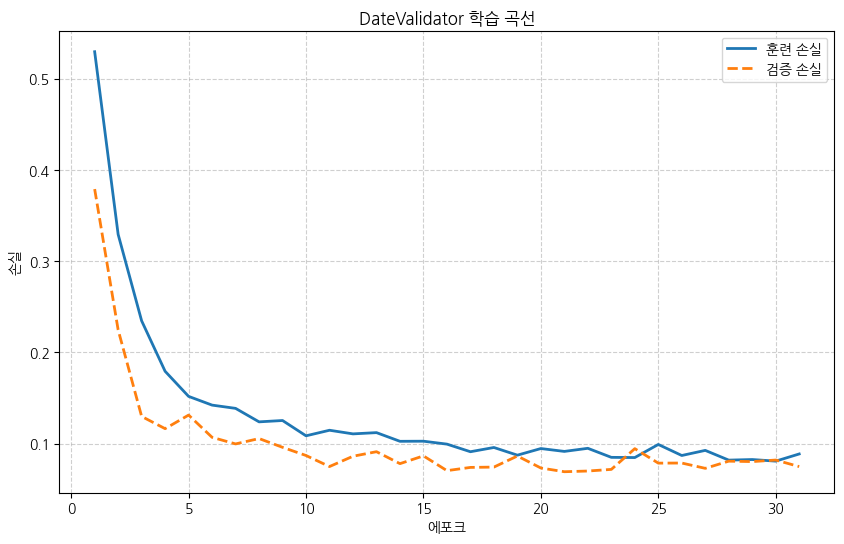

In [10]:
# 참고 - 학습 곡선 (EpochLogger 내장 plot, §7.7)
history['log'].plot(title='DateValidator 학습 곡선')

## [코드 10-8] 신뢰도를 함께 출력하는 예측 함수

로짓을 소프트맥스로 확률화해, 예측한 분류에 해당하는 확률을 신뢰도로
함께 반환한다. 정상은 `O`, 비정상은 `X`로 표기한다.

In [ ]:
###############################################################################
# 코드 10-8 - 분류 결과의 신뢰도를 계산하는 예측 함수
###############################################################################
def predict(model, input_str, vocab, device):
    model.eval()
    with torch.no_grad():
        ids = [CLS_IDX] + vocab.encode(input_str)
        src = torch.LongTensor(ids).unsqueeze(0).to(device)
        logits = model(src)
        # 예측 신뢰도 계산
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(1).item()
        confidence = probs[0][pred].item()
        # 정상 문자열은 O, 비정상 문자열은 X 를 반환
        label = 'O' if pred == 1 else 'X'
    return label, confidence


# 본문에 나온 테스트 케이스 예시 검증
test_cases = [
    ('02 Mar 2026', 'O'),
    ('02 March 2026', 'O'),
    ('Mar 02, 2026', 'O'),
    ('March 02, 2026', 'O'),
    ('02-03-2026', 'O'),
    ('2024/02/29', 'O'),         # 윤년의 2/29 = 정상
    ('30-10-2026', 'O'),
    ('Oct 31, 2026', 'O'),
    ('30-09-2026', 'O'),
    ('Hel low orld', 'X'),
    ('02 Mar, 2026', 'X'),
    ('March 02 2026', 'X'),
    ('2026-02-29', 'X'),         # 윤년 아닌 해의 2/29 = 비정상
    ('Sep 31, 2026', 'X'),
]

print(f'{"입력":<28s} {"정답":<5s} {"예측":<6s} {"신뢰도":<7s} 분류 성공 여부')
print('-' * 73)
for src_text, expected in test_cases:
    pred, conf = predict(model, src_text, vocab, device)
    ok = 'O' if pred == expected else 'X'
    print(f'{src_text!r:<33s} {expected:<7s} {pred:<5s} '
          f'{conf * 100:>5.1f}%                  {ok}')

입력                           정답    예측     신뢰도     분류 성공 여부
-------------------------------------------------------------------------
'02 Mar 2026'                     O       O      99.9%                  O
'02 March 2026'                   O       O      99.9%                  O
'Mar 02, 2026'                    O       O      99.9%                  O
'March 02, 2026'                  O       O      99.9%                  O
'02-03-2026'                      O       O      52.8%                  O
'2024/02/29'                      O       X      57.4%                  X
'30-10-2026'                      O       O      99.9%                  O
'Oct 31, 2026'                    O       O      99.9%                  O
'30-09-2026'                      O       O      99.9%                  O
'Hel low orld'                    X       X     100.0%                  O
'02 Mar, 2026'                    X       X      99.9%                  O
'March 02 2026'                   X       X      99.9

## [표 10-7] 입력 유형별 분류 정확도와 평균 신뢰도

유형별 데이터를 직접 만들어 200개씩 분류하고, 유형별 정확도와 평균
신뢰도를 집계한다. 데이터셋 설계의 한계로 일부 유형의 정확도가 낮게
나오는 현상을 직접 확인할 수 있다(자세한 분석은 연습 문제).

In [34]:
# 참고 - 입력 유형별 데이터 생성 함수
def gen_valid_dates(size):
    return [make_valid_date_str(d) for d in choice_random_dates(size)]


def gen_separator_errors(size):
    """구분자 형식 오류 - 22.09.2049 같은 형식."""
    out = []
    for d in choice_random_dates(size):
        sep = random.choice(['.', ' '])
        out.append(random.choice([
            f'{d.day:02d}{sep}{d.month:02d}{sep}{d.year}',
            f'{d.year}{sep}{d.month:02d}{sep}{d.day:02d}',
        ]))
    return out


def gen_year_position_errors(size):
    """연도 위치 오류 - 1976 Jan, 03 처럼 연도가 앞에."""
    out = []
    for d in choice_random_dates(size):
        m = calendar.month_abbr[d.month]
        out.append(f'{d.year} {m}, {d.day:02d}')
    return out


def gen_invalid_dates(size):
    """존재하지 않는 날짜 - Jun 65, 1928 등."""
    out = []
    for d in choice_random_dates(size):
        m = calendar.month_abbr[d.month]
        bad_day = random.randint(32, 80)  # 32 ~ 80 사이 무작위 일자
        out.append(f'{m} {bad_day}, {d.year}')
    return out


def gen_padding_zero_missing(size):
    """두 자리 월/일에서 0 누락 - 2035-6-10."""
    out = []
    for d in choice_random_dates(size):
        m_str = f'{d.month}' if d.month < 10 else f'{d.month:02d}'
        day_str = f'{d.day}' if d.day < 10 else f'{d.day:02d}'
        # 둘 다 두 자리면 강제로 한 자리 형식으로 (0 누락 유형 보장)
        if d.month >= 10 and d.day >= 10:
            day_str = f'{d.day % 10}'
        out.append(f'{d.year}-{m_str}-{day_str}')
    return out


def gen_random_strings(size):
    """임의 문자열 - CykTqWierwT1 같은 무작위 영숫자."""
    chars = string.ascii_letters + string.digits
    return [
        ''.join(random.choices(chars, k=random.randint(10, 14)))
        for _ in range(size)
    ]


categories = [
    ('유효한 날짜 문자열', gen_valid_dates, 1),
    ('구분자 형식 오류', gen_separator_errors, 0),
    ('연도 위치 오류', gen_year_position_errors, 0),
    ('존재하지 않는 날짜', gen_invalid_dates, 0),
    ('두 자리 월/일에서 0 누락', gen_padding_zero_missing, 0),
    ('임의 문자열', gen_random_strings, 0),
]

# 각 유형별 200 샘플 생성 후 정확도와 평균 신뢰도 측정
random.seed(2026)   # 재현성을 위한 별도 시드
CATEGORY_SIZE = 200
print(f'{"입력 유형":<28s} {"예시":<20s} {"정답":<7s} '
      f'{"정확도(%)":<10s} {"평균 신뢰도(%)":<12s}')
print('-' * 90)
for name, gen_fn, label in categories:
    samples = gen_fn(CATEGORY_SIZE)
    correct_size, conf_sum = 0, 0.0
    for s in samples:
        pred, conf = predict(model, s, vocab, device)
        truth = 'O' if label == 1 else 'X'
        if pred == truth:
            correct_size += 1
        conf_sum += conf
    acc = correct_size / CATEGORY_SIZE * 100
    avg_conf = conf_sum / CATEGORY_SIZE * 100
    truth_str = '정상' if label == 1 else '비정상'
    print(f'{name:<28s} {samples[0]!r:<20s} {truth_str:<7s} '
          f'{acc:<10.1f} {avg_conf:<12.1f}')

입력 유형                        예시                   정답      정확도(%)     평균 신뢰도(%)   
------------------------------------------------------------------------------------------
유효한 날짜 문자열                   '05/17/1921'         정상      95.5       95.8        
구분자 형식 오류                    '18.02.1961'         비정상     49.5       99.2        
연도 위치 오류                     '1967 Sep, 09'       비정상     100.0      99.4        
존재하지 않는 날짜                   'Jan 59, 1939'       비정상     0.0        99.9        
두 자리 월/일에서 0 누락              '1945-5-26'          비정상     0.0        99.7        
임의 문자열                       'hXyl7MzIaIe28c'     비정상     52.5       93.9        
